In [8]:
import pandas as pd   
df = pd.read_csv("Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


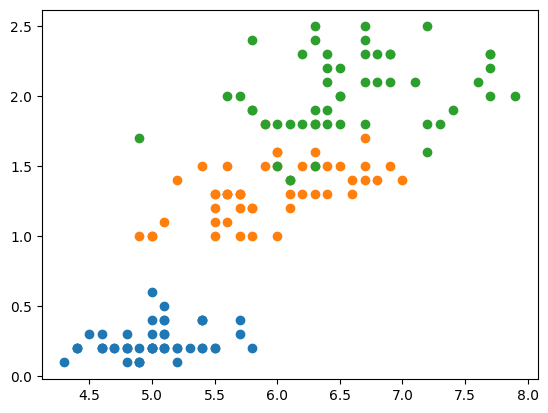

In [19]:
from matplotlib import pyplot as plt
for i in df["Species"].unique():
    plt.scatter(df[df["Species"]==i]["SepalLengthCm"], df[df["Species"]==i]["PetalWidthCm"])
    
plt.plot()
plt.show()

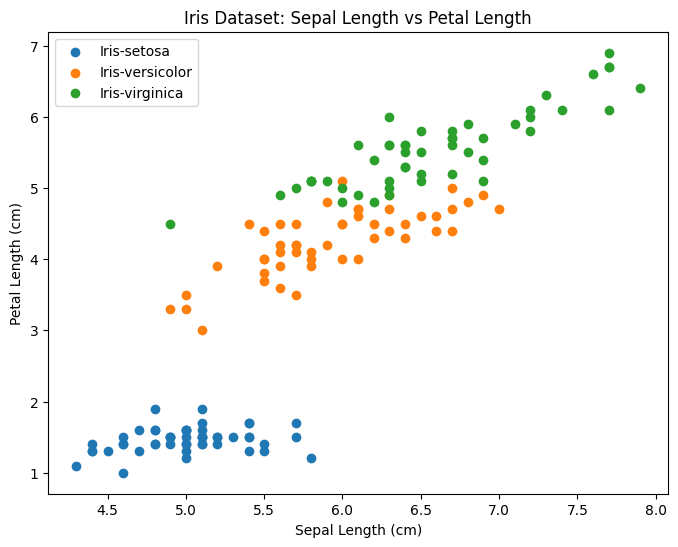

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Iris-setosa': 'tab:blue',
 'Iris-versicolor': 'tab:orange',
 'Iris-virginica': 'tab:green'}
for species, color in colors.items():
    subset = df[df["Species"] == species]
    ax.scatter(
        subset["SepalLengthCm"],
        subset["PetalLengthCm"],
        label=species,
        color=color
    )

ax.set_title("Iris Dataset: Sepal Length vs Petal Length")
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Petal Length (cm)")
ax.legend()
plt.show()


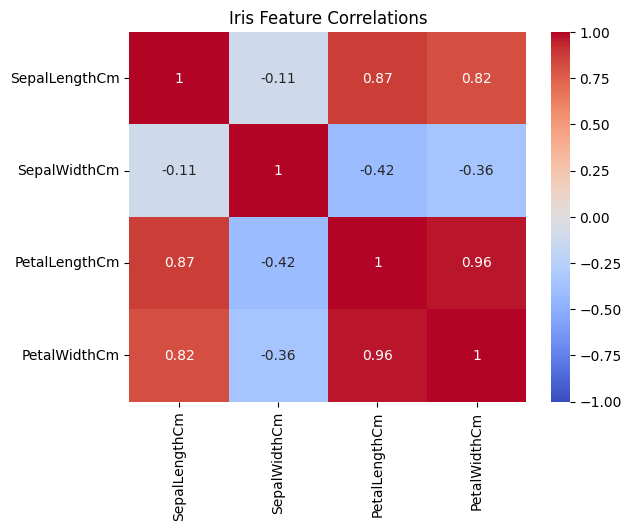

In [30]:
import seaborn as sns

correlation = df.drop(columns=["Id"]).select_dtypes("number").corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Iris Feature Correlations")
plt.show()

In [45]:
df_numeric = df.drop(columns=["Species"])
df_numeric
df_centered = df_numeric - df_numeric.mean()
df_centered

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [80]:
covariance_matrix = df_centered.cov()
covariance_matrix

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,0.685694,-0.039268,1.273682,0.516904
SepalWidthCm,-0.039268,0.188004,-0.321713,-0.117981
PetalLengthCm,1.273682,-0.321713,3.113179,1.296387
PetalWidthCm,0.516904,-0.117981,1.296387,0.582414


In [84]:
import numpy as np

# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort eigenvalues from largest to smallest
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Contribution of each PC
shared_inertia = eigenvalues / eigenvalues.sum()

print("Eigenvalues:", eigenvalues)
print("Shared inertia:", shared_inertia)

# Keep first two PCs
retained_PCs = eigenvectors[:, :2]

# Project centered data
projected_data = df_centered @ retained_PCs


Eigenvalues: [4.22484077 0.24224357 0.07852391 0.02368303]
Shared inertia: [0.92461621 0.05301557 0.01718514 0.00518309]


In [85]:
std = df_numeric.std(ddof=1).values

correlations = (
    retained_PCs
    * np.sqrt(eigenvalues[:2])
    / std[:, None]
)

correlations

array([[ 0.89754488, -0.39023141],
       [-0.38999338, -0.82831259],
       [ 0.99785405,  0.04903006],
       [ 0.96648418,  0.04818017]])

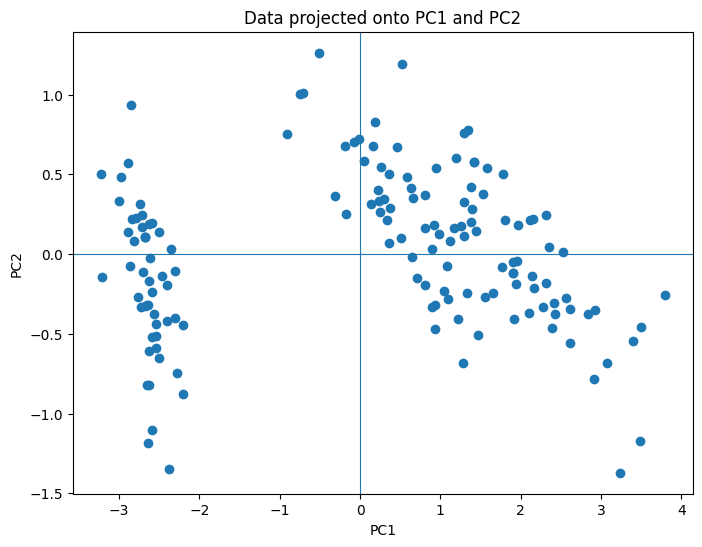

In [87]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    projected_data.iloc[:, 0],
    projected_data.iloc[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data projected onto PC1 and PC2")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.show()

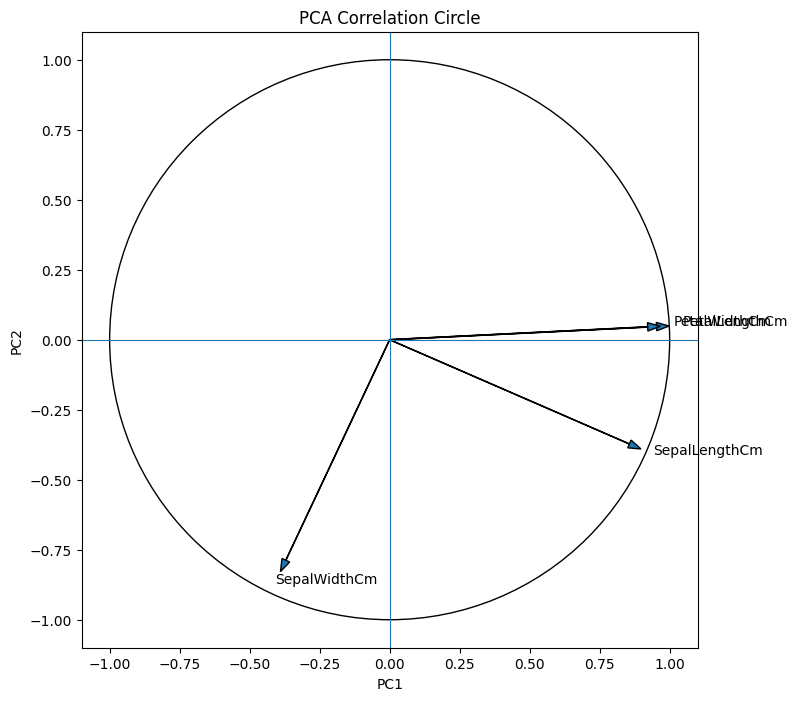

In [88]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

# Circle
circle = plt.Circle((0, 0), 1, fill=False)
ax.add_artist(circle)

# Draw variables
for i, variable in enumerate(df_numeric.columns):
    x = correlations[i, 0]
    y = correlations[i, 1]

    ax.arrow(
        0, 0, x, y,
        head_width=0.03,
        length_includes_head=True
    )

    ax.text(x * 1.05, y * 1.05, variable, fontsize=10)

# Axes
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA Correlation Circle")

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")

plt.show()